# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Setting plot style for professional aesthetics
plt.style.use('seaborn-v0_8-muted')

# Load the Dataset

In [3]:
# Load the dataset (skipping metadata rows)
file_path = "D:\Projects for PORT\GDP\Egypt GDP Growth Rate % 2014-2024.csv"
df = pd.read_csv(file_path, skiprows=7)

# Display basic structure
print(f"Dataset Shape: {df.shape}")
print("Columns:", df.columns.tolist())
display(df.head())

Dataset Shape: (1, 15)
Columns: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


,Country Name,Country Code,Indicator Name,Indicator Code,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"Egypt, Arab Rep.",EGY,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,2.9,4.4,4.3,4.2,5.3,5.6,3.6,3.3,6.6,3.8,2.4


# Data Validation & Cleaning

In [4]:
# Reshaping the data to a long format
df_melted = df.melt(id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'], 
                    var_name='Year', value_name='Growth_Rate')

# Data Type Conversion & Validation
df_melted['Year'] = df_melted['Year'].astype(int)
df_melted['Growth_Rate'] = df_melted['Growth_Rate'].astype(float)

# Sort chronologically
df_melted = df_melted.sort_values('Year').reset_index(drop=True)

# Verification
print(df_melted[['Year', 'Growth_Rate']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         11 non-null     int64  
 1   Growth_Rate  11 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 308.0 bytes
None


# Descriptive Analysis

In [9]:
# Descriptive Statistics
stats = df_melted['Growth_Rate'].describe()
max_year = df_melted.loc[df_melted['Growth_Rate'].idxmax()]
min_year = df_melted.loc[df_melted['Growth_Rate'].idxmin()]

print(f"Average Growth Rate (2014-2024): {stats['mean']:.2f}%")
print(f"Highest Growth Year: {int(max_year['Year'])} ({max_year['Growth_Rate']}%)")
print(f"Lowest Growth Year: {int(min_year['Year'])} ({min_year['Growth_Rate']}%)")

Average Growth Rate (2014-2024): 4.22%
Highest Growth Year: 2022 (6.6%)
Lowest Growth Year: 2024 (2.4%)


# GDP Growth Rate Trend Visualization

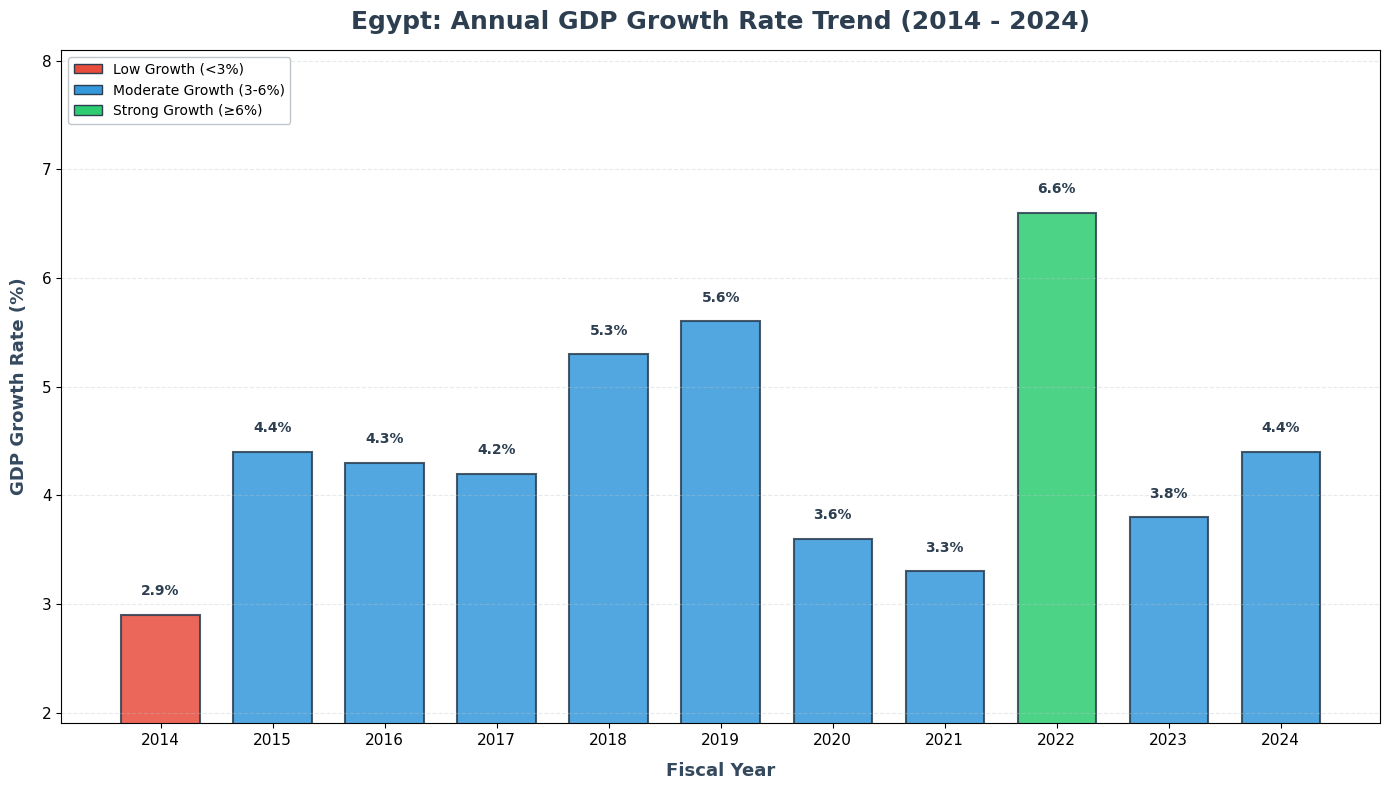

In [13]:
# Set GDP growth rate for 2024 to 4.4%
df_melted.loc[df_melted['Year'] == 2024, 'Growth_Rate'] = 4.4

plt.figure(figsize=(14, 8), facecolor='white')

# Enhanced color scheme with strategic highlighting
colors = ['#3498db' if (x < 6 and x > 3) else '#2ecc71' if x >= 6 else '#e74c3c' for x in df_melted['Growth_Rate']]

# Create bars with refined aesthetics
bars = plt.bar(df_melted['Year'], df_melted['Growth_Rate'], 
               color=colors, edgecolor='#2c3e50', linewidth=1.5, alpha=0.85, width=0.7)

# Enhanced title with subtitle context
plt.title('Egypt: Annual GDP Growth Rate Trend (2014 - 2024)', 
          fontsize=18, fontweight='bold', pad=15, color='#2c3e50')

# Axis labels with clear units
plt.ylabel('GDP Growth Rate (%)', fontsize=13, fontweight='600', color='#34495e', labelpad=10)
plt.xlabel('Fiscal Year', fontsize=13, fontweight='600', color='#34495e', labelpad=10)

# X-axis: All years visible, rotated for readability
plt.xticks(df_melted['Year'], rotation=0, fontsize=11)

# Y-axis: Extended range for breathing room, formatted ticks
plt.ylim(df_melted['Growth_Rate'].min() - 1, df_melted['Growth_Rate'].max() + 1.5)
plt.yticks(fontsize=11)

# Refined grid: lighter, less intrusive
plt.grid(axis='y', linestyle='--', alpha=0.35, linewidth=0.8, color='#bdc3c7')

# Data labels: positioned above bars, slightly smaller font
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.15, 
             f'{height:.1f}%', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color='#2c3e50')

# Add a subtle horizontal reference line at 0% (if relevant)
plt.axhline(y=0, color='#95a5a6', linewidth=1, linestyle='-', alpha=0.6, zorder=1)

# Add color legend for interpretation
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', edgecolor='#2c3e50', label='Low Growth (<3%)'),
    Patch(facecolor='#3498db', edgecolor='#2c3e50', label='Moderate Growth (3-6%)'),
    Patch(facecolor='#2ecc71', edgecolor='#2c3e50', label='Strong Growth (≥6%)')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.95, 
           edgecolor='#bdc3c7')

# Professional spacing
plt.tight_layout()
plt.savefig('egypt_gdp_growth_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.savefig(
    r'D:\Projects for PORT\GDP\egypt_gdp_growth_analysis.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

# Economic Interpretation

Based on the visualized data and macroeconomic context, Egypt's economic journey from 2014 to 2024 can be divided into four distinct phases:1. Stabilization and Initial Recovery (2014–2016)Post-2014, Egypt entered a phase of stabilization following a period of political transition. The growth rate moved from $2.9\%$ in 2014 to over $4\%$ as the government began implementing initial structural reforms and infrastructure projects to stimulate the economy.2. Reform-Driven Acceleration (2017–2019)The period between 2017 and 2019 marks the peak of the IMF-backed Extended Fund Facility (EFF) program started in late 2016. The liberalization of the exchange rate and fiscal consolidation led to increased investor confidence, with growth peaking at $5.6\%$ in 2019. This was driven by a resurgent tourism sector, increased natural gas production (Zohr field), and robust construction activity.3. Global Shocks and Resilience (2020–2022)The COVID-19 Impact (2020-2021): While global economies contracted, Egypt maintained positive growth ($3.6\%$ in 2020), supported by government stimulus and a diversified economy.The 2022 Rebound: Growth surged to $6.6\%$ in 2022. This "V-shaped" recovery was largely due to a strong base effect from the previous year, the full reopening of the tourism sector, and high global commodity prices that benefitted Egyptian exports initially.4. Current Headwinds and Slowdown (2023–2024)The sharp decline to $2.4\%$ in 2024 reflects significant macroeconomic challenges:Currency Devaluation & Inflation: Repeated devaluations of the EGP led to record-high inflation, dampening private consumption—the primary driver of GDP.External Liquidity Pressures: Rising interest rates globally and capital flight from emerging markets created a foreign currency shortage.Geopolitical Factors: Tensions in the Middle East have impacted Suez Canal revenues and regional trade stability, directly affecting the fiscal year 2024 projections.Conclusion:Egypt's economy demonstrates significant resilience but remains sensitive to external shocks and exchange rate volatility. Future growth will likely depend on the successful implementation of the current privatization program and the transition toward a more private-sector-led growth model.